# Aprendizaje no supervisado - Aplicación sobre EPH

La **Encuesta Permanente de Hogares** es un programa nacional cuyo propósito es el relevamiento sistemático y permanente de los datos referidos a las características demográficas y socioeconómicas fundamentales de la población, vinculadas a la fuerza de trabajo. Su temática está orientada hacia la **caracterización de la situación social integral de los individuos y los hogares**, aunque los datos más difundidos son los relacionados con el mercado laboral.

La Encuesta Permanente de Hogares (EPH), que desde 1973 se realizaba a través de la medición puntual de dos ondas anuales (mayo y octubre), pasó en 2003 a ser un relevamiento continuo con datos publicados con frecuencia trimestral.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## Metodología de EPH



Nos enfocaremos en la EPH realizada sobre hogares (también se publica sobre individuos). De allí nos interesará buscar segmentar a los hogares siguiendo variables que hablen de la situación socioeconómica de ese hogar. La información del diseño y su estructura la pueden ver acá: https://www.indec.gob.ar/ftp/cuadros/menusuperior/eph/EPH_registro_4T2024.pdf

Vamos a separar algunas variables y englobarlas en categorías que hacen a la vivienda o el hogar que tomaremos en este análisis.

| Categoría                   | Variables                             | Descripción                                                      |
| --------------------------- | ------------------------------------------------ | ---------------------------------------------------------------- |
| Características de vivienda | `IV1`, `IV2`, `IV3`, `IV6`, `IV7`, `IV8`, `IV11` | Tipo de vivienda, ambientes, piso, acceso al agua y saneamiento. |
| Composición del hogar       | `IX_TOT`, `IX_MEN10`, `IX_MAYEQ10`               | Cantidad de integrantes, menores de 10 años.                     |
| Ingresos                    | `ITF`, `IPCF`, `DECIFR`, `DECCFR`                | Ingreso total y per cápita + deciles.                            |
| Estrategias económicas      | `V1` a `V10`                                     | Cómo se sostienen (trabajo, jubilación, subsidios, préstamos).   |
| Tenencia / condiciones      | `II7`, `II9`                                     | Situación habitacional y uso del baño.                           |


### Características de vivienda y composición de hogar + ingresos

Tomaremos de la encuesta información relevante a como es la vivienda:

- Tipo de vivienda
- Tipo de pisos
- Cantidad de ambientes
- Cubierta o techo. ¿Cómo son?
- Situación sanitaria
- Cloacas

- Cantidad de miembros en familia y distribución de edades
- Ingreso del grupo familiar

#### Información de variables que agruparemos en este apartado

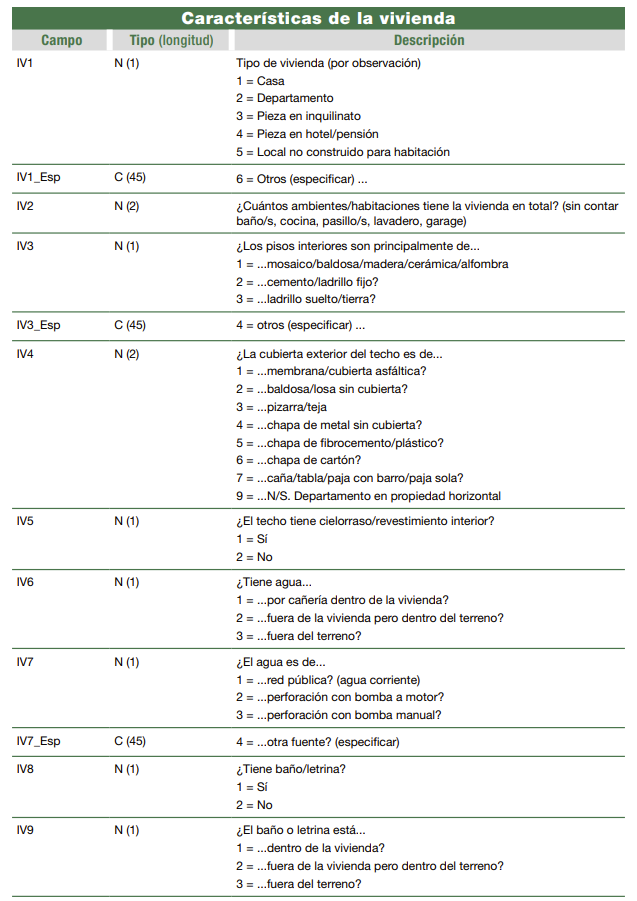
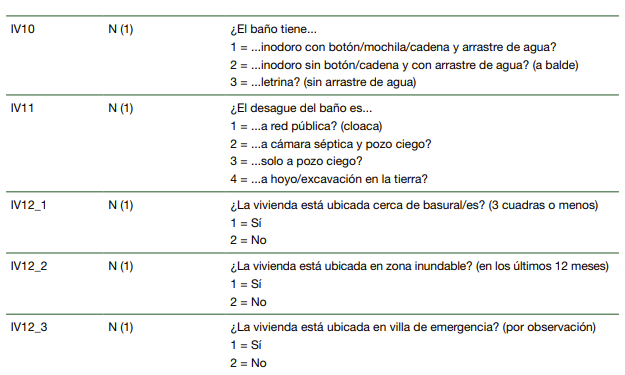
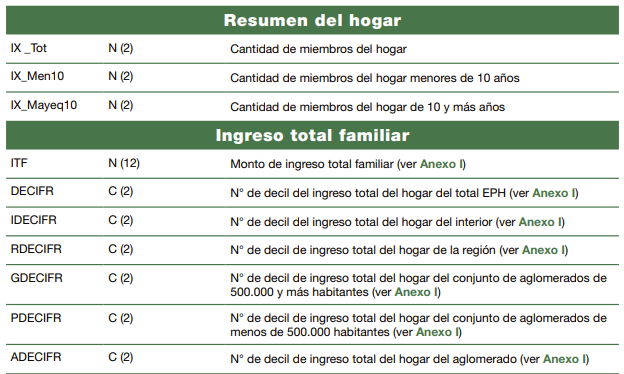

### Estrategias del hogar

Dentro de esta categoría estamos englobando variables que tienen que ver a la naturaleza de sus ingresos o de donde provienen. En líneas generales las variables previas nos describen cómo es el hogar y las que siguen en cómo se sustenta.

#### Información de variables que agruparemos en este apartado

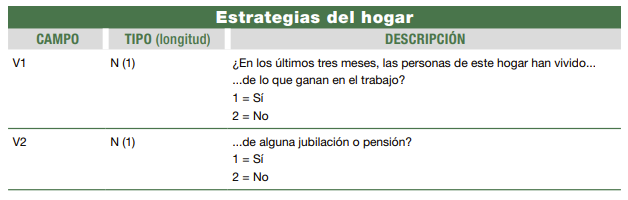
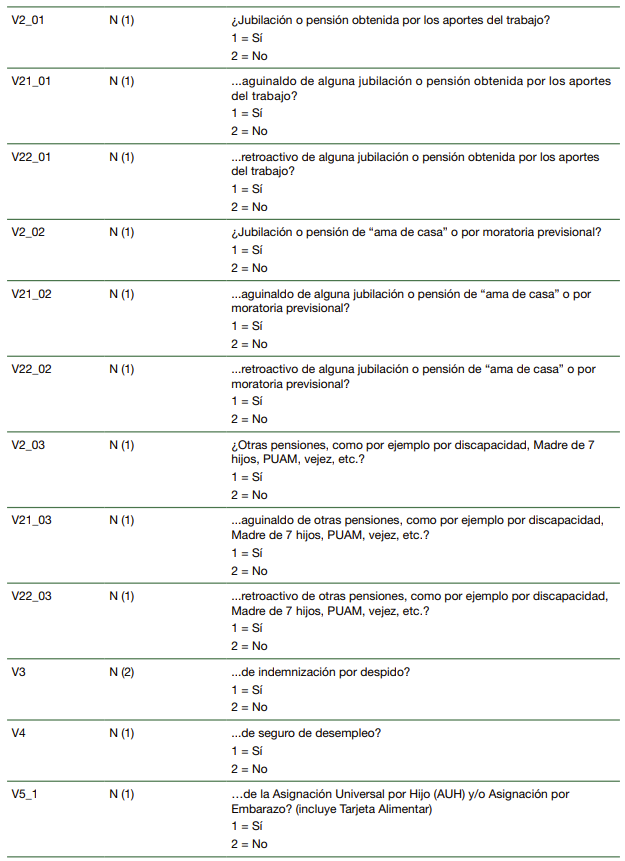
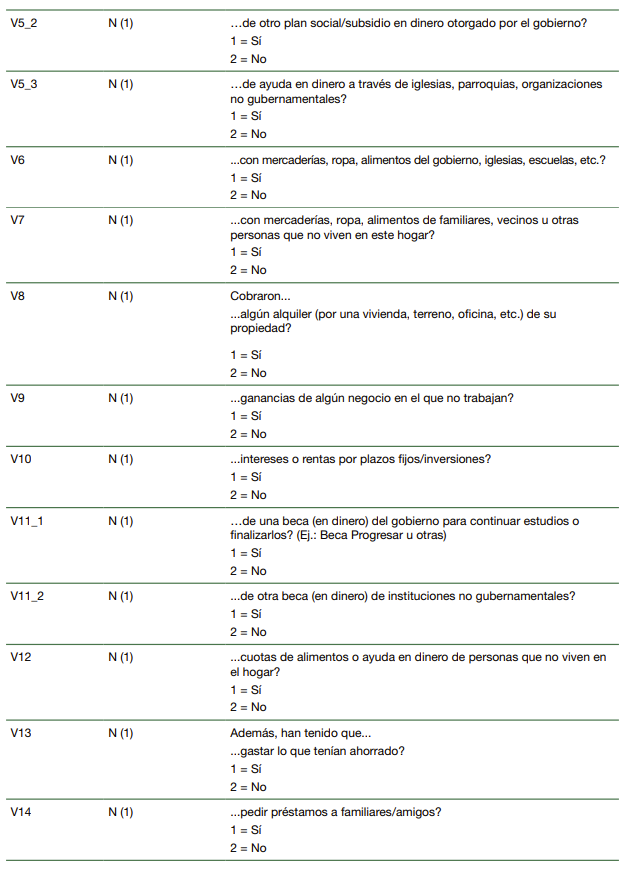
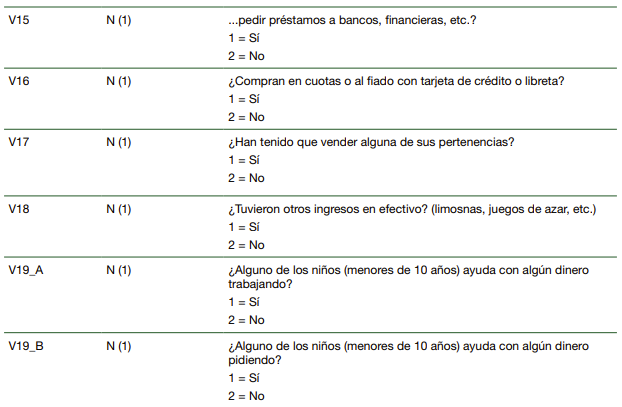

In [2]:
# Diccionario con descripción de variables del análisis EPH, para fácil acceos luego
descripcion_variables = {
    "CODUSU": "Código único del hogar",
    "REGION": "Región estadística del país",
    "AGLOMERADO": "Identificador del aglomerado urbano",
    "IV1": "Tipo de vivienda",
    "IV2": "Cantidad de ambientes",
    "IV3": "Material del piso de la vivienda",
    "IV6": "¿Tiene agua por cañería dentro de la vivienda?",
    "IV7": "Origen del agua",
    "IV8": "¿Es agua potable?",
    "IV11": "¿Tiene baño dentro de la vivienda?",
    "IX_TOT": "Cantidad total de miembros del hogar",
    "IX_MEN10": "Cantidad de miembros menores de 10 años",
    "IX_MAYEQ10": "Cantidad de miembros de 10 años o más",
    "ITF": "Ingreso total familiar",
    "IPCF": "Ingreso per cápita familiar",
    "DECIFR": "Decil de ingreso total familiar",
    "DECCFR": "Decil de ingreso per cápita familiar",
    "II7": "Condición de tenencia de la vivienda",
    "II9": "Uso exclusivo del baño",
    "V1": "Viven de lo que ganan en el trabajo",
    "V2": "Reciben jubilación o pensión",
    "V2_02": "Cantidad de perceptores de jubilación",
    "V2_03": "Monto total jubilación/pensión",
    "V21_01": "Reciben pensión por viudez",
    "V22_01": "Reciben pensión por invalidez",
    "V3": "Reciben pensión no contributiva",
    "V4": "Reciben AUH/Asignación Familiar",
    "V5_02": "Perciben plan social",
    "V5_03": "Monto total del plan social",
    "V6": "Reciben ayuda de otras personas",
    "V7": "Reciben ayuda de instituciones",
    "V8": "Ingresos por alquiler o renta",
    "V9": "Tienen negocio propio",
    "V10": "Trabajan por cuenta propia informal",
    "V11_01": "Reciben beca (niños)",
    "V11_02": "Reciben beca (adultos)",
    "V12": "Tienen tarjeta de alimentos",
    "V13": "Reciben dinero de otro hogar",
    "V14": "Venden bienes",
    "V15": "Reciben bolsones/comida",
    "V16": "Viven de changas",
    "V17": "Ayuda de organizaciones sociales",
    "V18": "Venden en la vía pública",
    "V19_A": "Prestación por discapacidad",
    "V19_B": "Otras estrategias"
}

# Convertir a DataFrame
df_desc = pd.DataFrame.from_dict(descripcion_variables, orient='index', columns=["descripcion"])
df_desc.index.name = "variable"



In [3]:
df_desc

,descripcion
variable,
CODUSU,Código único del hogar
REGION,Región estadística del país
AGLOMERADO,Identificador del aglomerado urbano
IV1,Tipo de vivienda
IV2,Cantidad de ambientes
IV3,Material del piso de la vivienda
IV6,¿Tiene agua por cañería dentro de la vivienda?
IV7,Origen del agua
IV8,¿Es agua potable?


## Preprocesamiento del dataset

In [4]:
# Descargamos la última EPH publicada por INDEC. Se publica en xlsx pero la convertí previamente a csv
!gdown --id 1PxXUyRmzHTfPBTEwes5uYpncYlPguqd4

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1PxXUyRmzHTfPBTEwes5uYpncYlPguqd4
To: /content/usu_hogar_T424.csv
100% 3.93M/3.93M [00:00<00:00, 211MB/s]


In [5]:
eph = pd.read_csv('usu_hogar_T424.csv',sep=";")

<ipython-input-5-4159938250>:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  eph = pd.read_csv('usu_hogar_T424.csv',sep=";")


Esta es la EPH sin procesar. Tiene:


- 16.511 hogares
- 97 variables

Este alcance lo recortaremos en base a lo comentado atrás.



In [6]:
eph.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16511 entries, 0 to 16510
Data columns (total 98 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CODUSU      16511 non-null  object 
 1   ANO4        16511 non-null  int64  
 2   TRIMESTRE   16511 non-null  int64  
 3   NRO_HOGAR   16511 non-null  int64  
 4   REALIZADA   16511 non-null  int64  
 5   REGION      16511 non-null  int64  
 6   MAS_500     16511 non-null  object 
 7   AGLOMERADO  16511 non-null  int64  
 8   PONDERA     16511 non-null  int64  
 9   IV1         16511 non-null  int64  
 10  IV1_ESP     20 non-null     object 
 11  IV2         16511 non-null  int64  
 12  IV3         16511 non-null  int64  
 13  IV3_ESP     35 non-null     object 
 14  IV4         16511 non-null  int64  
 15  IV5         16511 non-null  int64  
 16  IV6         16511 non-null  int64  
 17  IV7         16511 non-null  int64  
 18  IV7_ESP     19 non-null     object 
 19  IV8         16511 non-nul

Filtremos el dataset para quedarnos con las columnas que analizaremos descriptas arriba

In [7]:
total_eph = eph.columns

In [8]:
total_eph

Index(['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'REALIZADA', 'REGION',
       'MAS_500', 'AGLOMERADO', 'PONDERA', 'IV1', 'IV1_ESP', 'IV2', 'IV3',
       'IV3_ESP', 'IV4', 'IV5', 'IV6', 'IV7', 'IV7_ESP', 'IV8', 'IV9', 'IV10',
       'IV11', 'IV12_1', 'IV12_2', 'IV12_3', 'II1', 'II2', 'II3', 'II3_1',
       'II4_1', 'II4_2', 'II4_3', 'II5', 'II5_1', 'II6', 'II6_1', 'II7',
       'II7_ESP', 'II8', 'II8_ESP', 'II9', 'V1', 'V2', 'V2_02', 'V2_03',
       'V21_01', 'V22_01', 'V3', 'V4', 'V5_02', 'V5_03', 'V6', 'V7', 'V8',
       'V9', 'V10', 'V11_01', 'V11_02', 'V12', 'V13', 'V14', 'V15', 'V16',
       'V17', 'V18', 'V19_A', 'V19_B', 'IX_TOT', 'IX_MEN10', 'IX_MAYEQ10',
       'ITF', 'DECIFR', 'IDECIFR', 'RDECIFR', 'GDECIFR', 'PDECIFR', 'ADECIFR',
       'IPCF', 'DECCFR', 'IDECCFR', 'RDECCFR', 'GDECCFR', 'PDECCFR', 'ADECCFR',
       'PONDIH', 'VII1_1', 'VII1_2', 'VII2_1', 'VII2_2', 'VII2_3', 'VII2_4',
       'V5_01', 'V21_02', 'V21_03', 'V22_02', 'V22_03', 'V2_01'],
      dtype='object')

In [11]:
# Información del trimestre publicado y año
eph.TRIMESTRE.value_counts()
eph.ANO4.value_counts()

,count
ANO4,
2024,16511


In [ ]:
total_eph

Index(['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'REALIZADA', 'REGION',
       'MAS_500', 'AGLOMERADO', 'PONDERA', 'IV1', 'IV1_ESP', 'IV2', 'IV3',
       'IV3_ESP', 'IV4', 'IV5', 'IV6', 'IV7', 'IV7_ESP', 'IV8', 'IV9', 'IV10',
       'IV11', 'IV12_1', 'IV12_2', 'IV12_3', 'II1', 'II2', 'II3', 'II3_1',
       'II4_1', 'II4_2', 'II4_3', 'II5', 'II5_1', 'II6', 'II6_1', 'II7',
       'II7_ESP', 'II8', 'II8_ESP', 'II9', 'V1', 'V2', 'V2_02', 'V2_03',
       'V21_01', 'V22_01', 'V3', 'V4', 'V5_02', 'V5_03', 'V6', 'V7', 'V8',
       'V9', 'V10', 'V11_01', 'V11_02', 'V12', 'V13', 'V14', 'V15', 'V16',
       'V17', 'V18', 'V19_A', 'V19_B', 'IX_TOT', 'IX_MEN10', 'IX_MAYEQ10',
       'ITF', 'DECIFR', 'IDECIFR', 'RDECIFR', 'GDECIFR', 'PDECIFR', 'ADECIFR',
       'IPCF', 'DECCFR', 'IDECCFR', 'RDECCFR', 'GDECCFR', 'PDECCFR', 'ADECCFR',
       'PONDIH', 'VII1_1', 'VII1_2', 'VII2_1', 'VII2_2', 'VII2_3', 'VII2_4',
       'V5_01', 'V21_02', 'V21_03', 'V22_02', 'V22_03', 'V2_01'],
      dtype='object')

#### Ingeniería de atributos

In [12]:
# Filtrar variables seleccionadas mencionadas arriba
vars_basicas = ["CODUSU","REGION","AGLOMERADO",
    "IV1", "IV2", "IV3", "IV6", "IV7", "IV8", "IV11",
    "IX_TOT", "IX_MEN10", "IX_MAYEQ10",
    "ITF", "IPCF", "DECIFR", "DECCFR",
    "II7", "II9"
]
# Tomar solo columnas que empiezan con V1 a V19 y sus variantes (variables de ingreso)
vars_economicas =  ['V1', 'V2', 'V2_02', 'V2_03',
       'V21_01', 'V22_01', 'V3', 'V4', 'V5_02', 'V5_03', 'V6', 'V7', 'V8',
       'V9', 'V10', 'V11_01', 'V11_02', 'V12', 'V13', 'V14', 'V15', 'V16',
       'V17', 'V18', 'V19_A', 'V19_B']
vars_usar = vars_basicas + vars_economicas
df = eph[vars_usar].copy()


In [13]:
df

,CODUSU,REGION,AGLOMERADO,IV1,IV2,IV3,IV6,IV7,IV8,IV11,...,V11_02,V12,V13,V14,V15,V16,V17,V18,V19_A,V19_B
0,TQRMNORQYHJMKRCDEFOCD00875201,41,8,1,4,1,1,1,1,1,...,2,2,2,2,2,1,2,2,2,2
1,TQRMNOPWTHLMKQCDEFOCD00852402,41,8,1,2,1,1,1,1,2,...,2,2,2,2,2,2,2,2,2,2
2,TQSMNOUVVHKOLPCDEHPJB00875202,40,29,1,4,1,1,1,1,1,...,2,2,2,2,2,1,2,2,2,2
3,TQRMNOPRTHKOLQCDEHPJB00868781,40,29,1,2,1,1,1,1,3,...,2,2,2,2,2,1,2,2,2,2
4,TQRMNOQUSHKMLNCDEIIAD00868671,1,32,2,4,1,1,1,1,1,...,2,2,2,2,2,1,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16506,TQRMNOPWYHKMKQCDEGKDB00872409,43,14,2,3,1,1,1,1,1,...,2,2,2,2,1,1,1,2,2,2
16507,TQRMNOQYXHLMKOCDEGKDB00857184,43,14,1,4,1,1,1,1,1,...,2,2,1,2,2,2,2,2,2,2
16508,TQRMNOQRWHKNLTCDEFKID00871504,43,4,1,4,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
16509,TQRMNORVPHMOKMCDEOJAH00813428,44,93,1,3,1,1,1,1,1,...,2,2,2,2,2,1,2,2,2,2


In [14]:
def resumen_variables(df):
    """
     DataFrame con el mínimo, máximo y cantidad de valores distintos
    para cada columna del df dado.
    """
    resumen = pd.DataFrame({
        "min": df.min(numeric_only=True),
        "max": df.max(numeric_only=True),
        "n_distintos": df.nunique()
    })
    return resumen
resumen_variables(df)

,min,max,n_distintos
AGLOMERADO,2.0,93.0,32
CODUSU,NaN,NaN,16416
DECCFR,0.0,12.0,12
DECIFR,0.0,12.0,12
II7,0.0,9.0,10
II9,0.0,4.0,5
IPCF,NaN,NaN,2797
ITF,0.0,21950000.0,2133
IV1,1.0,6.0,6
IV11,0.0,4.0,5


In [15]:
df.columns

Index(['CODUSU', 'REGION', 'AGLOMERADO', 'IV1', 'IV2', 'IV3', 'IV6', 'IV7',
       'IV8', 'IV11', 'IX_TOT', 'IX_MEN10', 'IX_MAYEQ10', 'ITF', 'IPCF',
       'DECIFR', 'DECCFR', 'II7', 'II9', 'V1', 'V2', 'V2_02', 'V2_03',
       'V21_01', 'V22_01', 'V3', 'V4', 'V5_02', 'V5_03', 'V6', 'V7', 'V8',
       'V9', 'V10', 'V11_01', 'V11_02', 'V12', 'V13', 'V14', 'V15', 'V16',
       'V17', 'V18', 'V19_A', 'V19_B'],
      dtype='object')

Hay varios registros que tienen nulo de acuerdo a la metodología de hogares. Esos registros los eliminaremos en este análisis ya que veremos que no son tantos

In [16]:
df.V3.value_counts()

,count
V3,
2,16440
1,60
9,11


In [17]:

#Variables donde 9 representa "NS/NC"
variables_con_9 = [
    "V1", "V10", "V11_01", "V11_02", "V12", "V13", "V14", "V15", "V16",
    "V17", "V18", "V19_A", "V19_B", "V2", "V21_01", "V22_01", "V2_02",
    "V2_03", "V3", "V4", "V5_02", "V5_03", "V6", "V7", "V8", "V9"
]

# Reemplazar el valor 9 por np.nan solo en esas columnas
df[variables_con_9] = df[variables_con_9].replace(9, np.nan)

# Hagamos reemplazo de 98 y 99 por NaN que tambien siguen similar metodología
df.replace({98: np.nan, 99: np.nan}, inplace=True)


In [18]:
resumen_variables(df)

,min,max,n_distintos
AGLOMERADO,2.0,93.0,32
CODUSU,NaN,NaN,16416
DECCFR,0.0,12.0,12
DECIFR,0.0,12.0,12
II7,0.0,9.0,10
II9,0.0,4.0,5
IPCF,NaN,NaN,2797
ITF,0.0,21950000.0,2133
IV1,1.0,6.0,6
IV11,0.0,4.0,5


Siguiendo el análisis veamos lo siguiente:

- Tenemos algo extraño en dos variables. Los deciles debieran ir de 1 a 10. Son muchos registros por lo que a fines de la clase los dejaremos, pero debiéramos averiguar a qué se debe. En metodologías anteriores se indica que esos numeros se corresponden cuando no se declaran ingresos. Adoptaremos mismo criterio
- Hay variables binarias en las Vx codificadas como 1/2 por Si/No. Vamos a llevarlas a 1/0, similar a las otras.

In [19]:
df.DECCFR.value_counts()

,count
DECCFR,
12,4213
2,1389
6,1365
4,1341
3,1298
5,1217
1,1197
7,1162
8,1162


In [20]:
# Reemplazar categorías no válidas por NaN en los deciles
df["DECIFR"] = df["DECIFR"].replace({0: np.nan, 12: np.nan, 13: np.nan})
df["DECCFR"] = df["DECCFR"].replace({0: np.nan, 12: np.nan, 13: np.nan})


In [21]:
# Detectar columnas binarias codificadas como 1/2 y recodificarlas a 1/0
binarias_1_2 = [col for col in df.columns if df[col].dropna().isin([1, 2]).all()]
df[binarias_1_2] = df[binarias_1_2].replace({2: 0})

print(f"Variables recodificadas como binarias (1/0): {binarias_1_2}")


Variables recodificadas como binarias (1/0): ['IV8', 'V1', 'V2', 'V21_01', 'V22_01', 'V3', 'V4', 'V5_02', 'V5_03', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11_01', 'V11_02', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19_A', 'V19_B']


In [22]:
# Veamos el resultante de nulos previo a escalar y aplicar KMeans
# Cantidad de nulos por columna
nulos = df.isna().sum()

# Porcentaje de nulos por columna
porcentaje = df.isna().mean() * 100

# Unir en un solo DataFrame
nulos_df = pd.DataFrame({
    "n_nulos": nulos,
    "%_nulos": porcentaje.round(2)
}).sort_values(by="n_nulos", ascending=False)

display(nulos_df)


,n_nulos,%_nulos
DECCFR,4280,25.92
DECIFR,4280,25.92
IV2,14,0.08
V17,13,0.08
V16,13,0.08
V12,13,0.08
V19_B,13,0.08
V18,13,0.08
V19_A,13,0.08
V15,13,0.08


In [23]:
df.dropna(inplace=True)

In [24]:
# Hagamos drop de nulos
df.reset_index(inplace=True,drop=True)

In [25]:
df

,CODUSU,REGION,AGLOMERADO,IV1,IV2,IV3,IV6,IV7,IV8,IV11,...,V11_02,V12,V13,V14,V15,V16,V17,V18,V19_A,V19_B
0,TQRMNOPRTHKOLQCDEHPJB00868781,40,29,1,2.0,1,1,1,1,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,TQRMNOQUSHKMLNCDEIIAD00868671,1,32,2,4.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,TQRMNOUURHLOLRCDEIIAD00875203,1,32,2,2.0,1,1,1,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,TQRMNORRUHLOLSCDEIIAD00854854,1,32,1,3.0,1,1,1,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,TQRMNOQYYHJKLLCDEIIAD00875204,1,32,2,1.0,1,1,1,1,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12215,TQRMNOPWYHKMKQCDEGKDB00872409,43,14,2,3.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
12216,TQRMNOQYXHLMKOCDEGKDB00857184,43,14,1,4.0,1,1,1,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12217,TQRMNOQRWHKNLTCDEFKID00871504,43,4,1,4.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12218,TQRMNORVPHMOKMCDEOJAH00813428,44,93,1,3.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [26]:
# Reemplazar ',' por '.' y convertir a float en todo el DataFrame
df = df.applymap(lambda x: str(x).replace(',', '.') if isinstance(x, str) else x)

# Luego convertir columnas numéricas a float donde sea posible
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

<ipython-input-26-2424128211>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: str(x).replace(',', '.') if isinstance(x, str) else x)


**Del total de 16.511 hogares nos terminamos quedando con 12.220**

#### Escalado de variables

Debemos escalar las variables por estar calculando distancias en el algoritmo de KMeans. Excluyamos las variables asociadas a la ubicación.

Usaremos Standard pero perderemos interpretabilidad de las variables ordinales con este método.



In [27]:

# Variables a excluir
excluir = ['CODUSU', 'AGLOMERADO', 'REGION']

# Crear X: dataset solo con variables numéricas útiles para clustering
X = df.drop(columns=excluir)

# Escalar
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Variables escaladas. DataFrame resultante:")
display(X_scaled.head())


Variables escaladas. DataFrame resultante:


,IV1,IV2,IV3,IV6,IV7,IV8,IV11,IX_TOT,IX_MEN10,IX_MAYEQ10,...,V11_02,V12,V13,V14,V15,V16,V17,V18,V19_A,V19_B
0,-0.513705,-0.789392,-0.325371,-0.129628,-0.159383,0.039462,3.259191,-0.465145,-0.495486,-0.317111,...,-0.049609,-0.324164,-0.696025,-0.412235,-0.391213,0.919891,-0.298378,-0.053595,-0.009047,-0.009047
1,1.609215,0.903102,-0.325371,-0.129628,-0.159383,0.039462,-0.462640,-0.465145,-0.495486,-0.317111,...,-0.049609,-0.324164,-0.696025,-0.412235,-0.391213,0.919891,-0.298378,-0.053595,-0.009047,-0.009047
2,1.609215,-0.789392,-0.325371,-0.129628,-0.159383,0.039462,-0.462640,0.143819,-0.495486,0.423683,...,-0.049609,-0.324164,-0.696025,2.425800,-0.391213,-1.087085,-0.298378,-0.053595,-0.009047,-0.009047
3,-0.513705,0.056855,-0.325371,-0.129628,-0.159383,0.039462,-0.462640,0.143819,-0.495486,0.423683,...,-0.049609,-0.324164,1.436730,-0.412235,-0.391213,-1.087085,-0.298378,-0.053595,-0.009047,-0.009047
4,1.609215,-1.635639,-0.325371,-0.129628,-0.159383,0.039462,-0.462640,-1.074110,-0.495486,-1.057904,...,-0.049609,-0.324164,1.436730,-0.412235,-0.391213,0.919891,-0.298378,-0.053595,-0.009047,-0.009047


In [31]:
X_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12220 entries, 0 to 12219
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IV1         12220 non-null  float64
 1   IV2         12220 non-null  float64
 2   IV3         12220 non-null  float64
 3   IV6         12220 non-null  float64
 4   IV7         12220 non-null  float64
 5   IV8         12220 non-null  float64
 6   IV11        12220 non-null  float64
 7   IX_TOT      12220 non-null  float64
 8   IX_MEN10    12220 non-null  float64
 9   IX_MAYEQ10  12220 non-null  float64
 10  ITF         12220 non-null  float64
 11  IPCF        12220 non-null  float64
 12  DECIFR      12220 non-null  float64
 13  DECCFR      12220 non-null  float64
 14  II7         12220 non-null  float64
 15  II9         12220 non-null  float64
 16  V1          12220 non-null  float64
 17  V2          12220 non-null  float64
 18  V2_02       12220 non-null  float64
 19  V2_03       12220 non-nul

## Aplicación de KMeans

En este caso los grupos que buscamos encontrar son grupos de hogares segmentados en base a una encuesta que se hace de forma metódica y periódica.

Veamos que arroja el método del codo como cantidad de clusters a considerar...

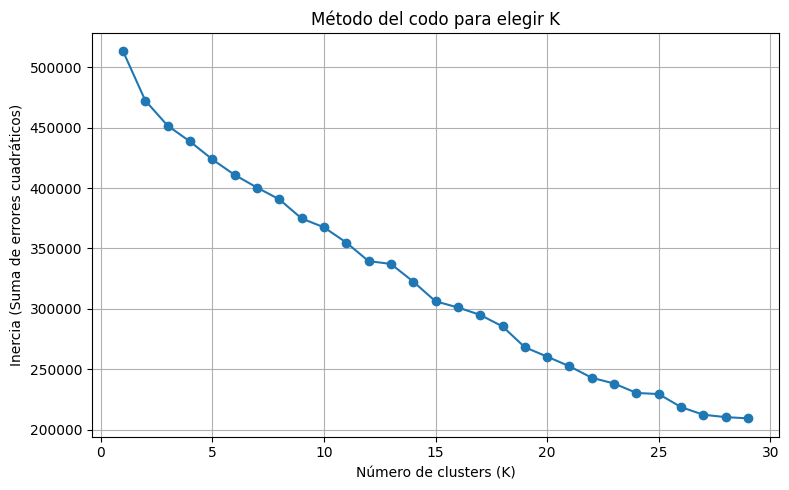

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Lista para almacenar la suma de errores cuadráticos
inertia = []
K_range = range(1, 30)
porcentaje = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        porcentaje.append((inertia[k-1] - inertia[k-2]) / inertia[k-2] * 100)

# Gráfico del método del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title("Método del codo para elegir K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (Suma de errores cuadráticos)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
porcentaje

[-7.985233600090861,
 -4.3828180086304585,
 -2.893417052534578,
 -3.373051442719005,
 -3.0332742322923627,
 -2.5479998031430315,
 -2.438876251876871,
 -4.052912191528021,
 -1.948553622406357,
 -3.429935380861187,
 -4.341028649185449,
 -0.680702762407795,
 -4.344792897467557,
 -5.058430951745347,
 -1.6507471712467285,
 -2.050725311738458,
 -3.2332630801995563,
 -6.032783700476614,
 -2.9049634318853332,
 -3.0624036245391664,
 -3.7748990978489405,
 -1.9476194737172776,
 -3.275794229934512,
 -0.41682674809849235,
 -4.708183817860173,
 -2.873884323907646,
 -0.936152456718943,
 -0.4853642451712708]

Segmentemos la población de hogares en 6 grupos, pensando en darle cierta interpretabilidad

In [30]:
# Aplicación de KMeans con 6 grupos
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters_6 = kmeans_6.fit_predict(X_scaled)

#Sillhouete
sil_score_6 = silhouette_score(X_scaled, clusters_6)

# Agregar clusters al DataFrame original con las variables geográficas
df_clusters_6 = df.loc[X_scaled.index].copy()
df_clusters_6["cluster"] = clusters_6



In [32]:
sil_score_6

np.float64(0.09094029119727336)

In [33]:
df

,CODUSU,REGION,AGLOMERADO,IV1,IV2,IV3,IV6,IV7,IV8,IV11,...,V11_02,V12,V13,V14,V15,V16,V17,V18,V19_A,V19_B
0,TQRMNOPRTHKOLQCDEHPJB00868781,40,29,1,2.0,1,1,1,1,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,TQRMNOQUSHKMLNCDEIIAD00868671,1,32,2,4.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,TQRMNOUURHLOLRCDEIIAD00875203,1,32,2,2.0,1,1,1,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,TQRMNORRUHLOLSCDEIIAD00854854,1,32,1,3.0,1,1,1,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,TQRMNOQYYHJKLLCDEIIAD00875204,1,32,2,1.0,1,1,1,1,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12215,TQRMNOPWYHKMKQCDEGKDB00872409,43,14,2,3.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
12216,TQRMNOQYXHLMKOCDEGKDB00857184,43,14,1,4.0,1,1,1,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12217,TQRMNOQRWHKNLTCDEFKID00871504,43,4,1,4.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12218,TQRMNORVPHMOKMCDEOJAH00813428,44,93,1,3.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [34]:
df_clusters_6.value_counts("cluster")

,count
cluster,
2,3930
1,3318
3,2716
5,2027
0,210
4,19


Y si probamos con 3 grupos ya que tenemos clusters poco poblados y un Sillhouete bastante lejos e 1?

In [35]:
# Aplicación de KMeans con 3 grupos
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_3 = kmeans_3.fit_predict(X_scaled)

#Sillhouete
sil_score_3 = silhouette_score(X_scaled, clusters_3)

# Agregar clusters al DataFrame original con las variables geográficas
df_clusters_3 = df.loc[X_scaled.index].copy()
df_clusters_3["cluster"] = clusters_3


In [36]:
sil_score_3

np.float64(0.09034369390193986)

In [37]:
df_clusters_3.value_counts("cluster")

,count
cluster,
2,4472
1,4338
0,3410


In [38]:
# Agrupar por AGLOMERADO y cluster
conteo = df_clusters_3.loc[X_scaled.index].groupby(["AGLOMERADO", "cluster"]).size().unstack(fill_value=0)

In [39]:
df_clusters_3

,CODUSU,REGION,AGLOMERADO,IV1,IV2,IV3,IV6,IV7,IV8,IV11,...,V12,V13,V14,V15,V16,V17,V18,V19_A,V19_B,cluster
0,TQRMNOPRTHKOLQCDEHPJB00868781,40,29,1,2.0,1,1,1,1,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
1,TQRMNOQUSHKMLNCDEIIAD00868671,1,32,2,4.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,TQRMNOUURHLOLRCDEIIAD00875203,1,32,2,2.0,1,1,1,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,TQRMNORRUHLOLSCDEIIAD00854854,1,32,1,3.0,1,1,1,1,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,TQRMNOQYYHJKLLCDEIIAD00875204,1,32,2,1.0,1,1,1,1,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12215,TQRMNOPWYHKMKQCDEGKDB00872409,43,14,2,3.0,1,1,1,1,1,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0
12216,TQRMNOQYXHLMKOCDEGKDB00857184,43,14,1,4.0,1,1,1,1,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
12217,TQRMNOQRWHKNLTCDEFKID00871504,43,4,1,4.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
12218,TQRMNORVPHMOKMCDEOJAH00813428,44,93,1,3.0,1,1,1,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0


##### Análisis de las variables socioeconómicas por cluster

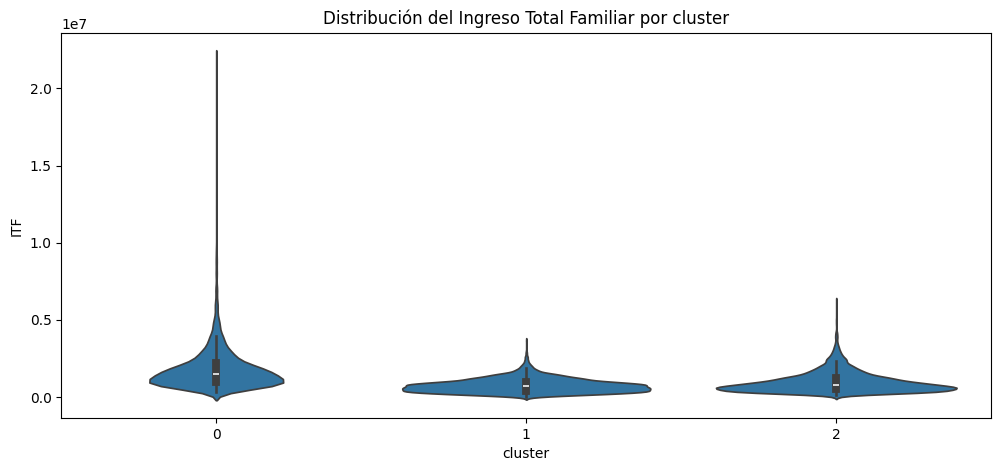

In [40]:
#Comenzemos por los ingresos

plt.figure(figsize=(12, 5))
sns.violinplot(data=df_clusters_3, x="cluster", y="ITF")  # ingreso total familiar
plt.title("Distribución del Ingreso Total Familiar por cluster")
plt.show()

In [41]:
# Y con las preguntas Si/No?

resumen_binarias = df_clusters_3.groupby("cluster")[binarias_1_2].mean().T #Trasponemos la matriz para ver las variables como filas
resumen_binarias.index.name = "variable"

resumen_con_desc = resumen_binarias.join(df_desc)

In [42]:
resumen_con_desc

,0,1,2,descripcion
variable,,,,
IV8,1.000000,0.996542,0.999106,¿Es agua potable?
V1,0.978592,0.928769,0.486807,Viven de lo que ganan en el trabajo
V2,0.026686,0.067543,1.000000,Reciben jubilación o pensión
V21_01,0.000000,0.000000,0.006708,Reciben pensión por viudez
V22_01,0.000880,0.001383,0.126342,Reciben pensión por invalidez
V3,0.004985,0.003919,0.000447,Reciben pensión no contributiva
V4,0.003226,0.005071,0.001565,Reciben AUH/Asignación Familiar
V5_02,0.002933,0.055786,0.012075,Perciben plan social
V5_03,0.000000,0.001153,0.000000,Monto total del plan social


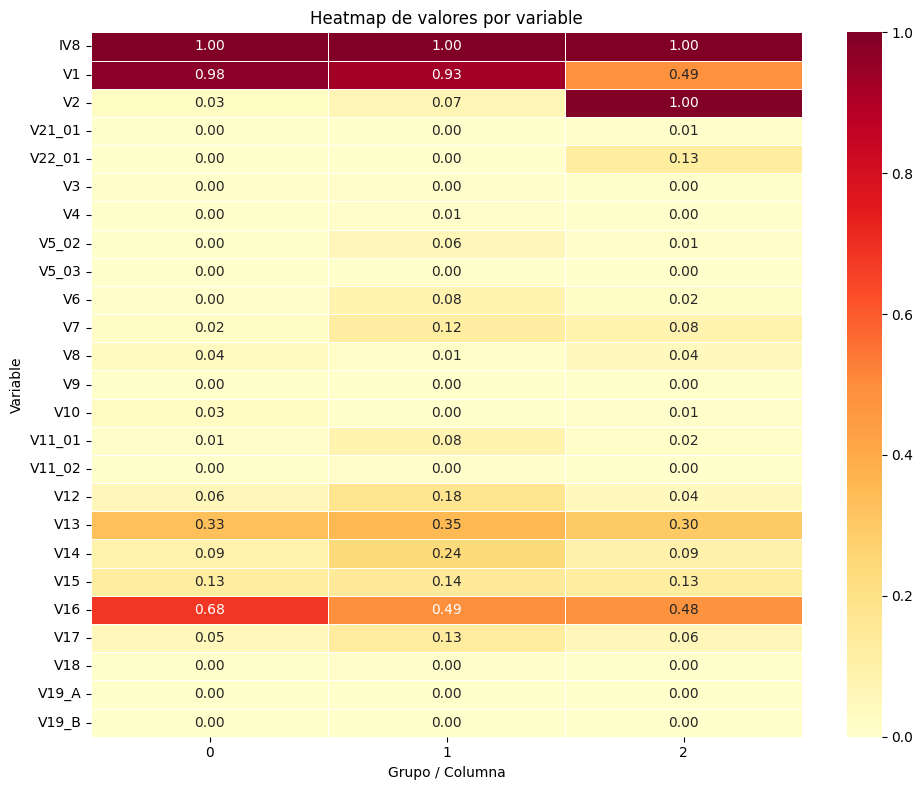

In [43]:
# Separá las columnas numéricas
df_values = resumen_con_desc[[0, 1, 2]]

# Plot del heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_values, annot=True, cmap="YlOrRd", linewidths=0.5, fmt=".2f")

plt.title("Heatmap de valores por variable")
plt.xlabel("Grupo / Columna")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


##### Hagamos PCA y veamos que componentes inciden en mayor medida o tienen mayor influencia en las primeras dos componentes

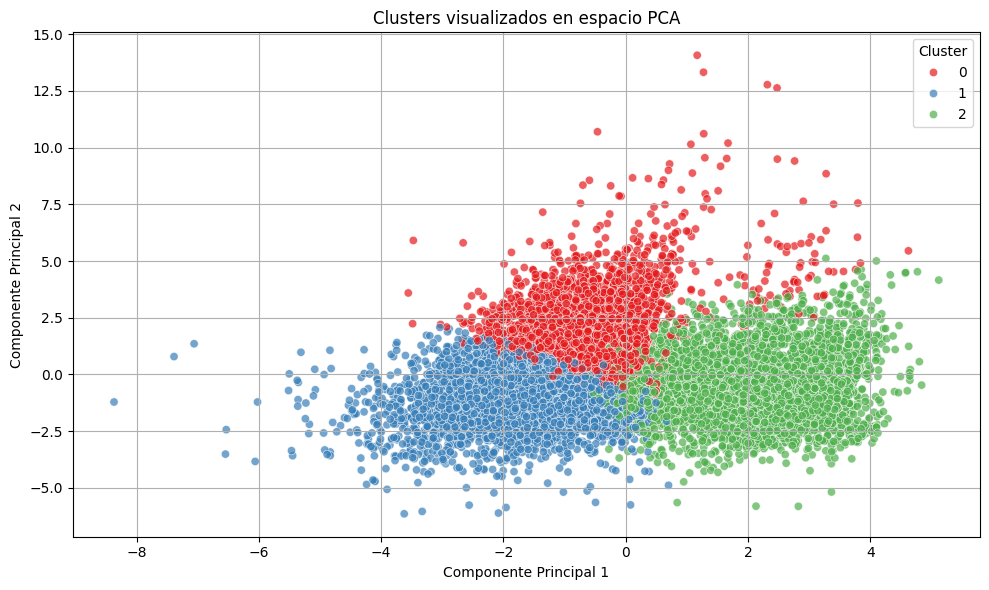

[0.09199607 0.17696804]


In [44]:
# PCA e inicialización. Planteamos 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# DataFrame con PCA y clusters
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_scaled.index)
df_pca["cluster"] = clusters_3

# Gráfico PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster", palette="Set1", alpha=0.7)
plt.title("Clusters visualizados en espacio PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# Pesos de las variables en los componentes principales
pca_components = pd.DataFrame(
    pca.components_,
    columns=X_scaled.columns,
    index=["PC1", "PC2"]
).T

# Ordenar por importancia en PC1
pca_components_sorted = pca_components.abs().sort_values(by="PC1", ascending=False)
print(pca.explained_variance_ratio_.cumsum())

In [45]:
df_pca

,PC1,PC2,cluster
0,1.235657,-0.227503,2
1,-0.235167,2.523769,0
2,-2.061185,-1.691336,1
3,1.319645,0.442080,2
4,0.189328,2.598748,0
...,...,...,...
12215,-0.938613,0.658068,0
12216,-0.762328,-1.157093,1
12217,3.298382,-1.490102,2
12218,-2.008910,2.504368,0


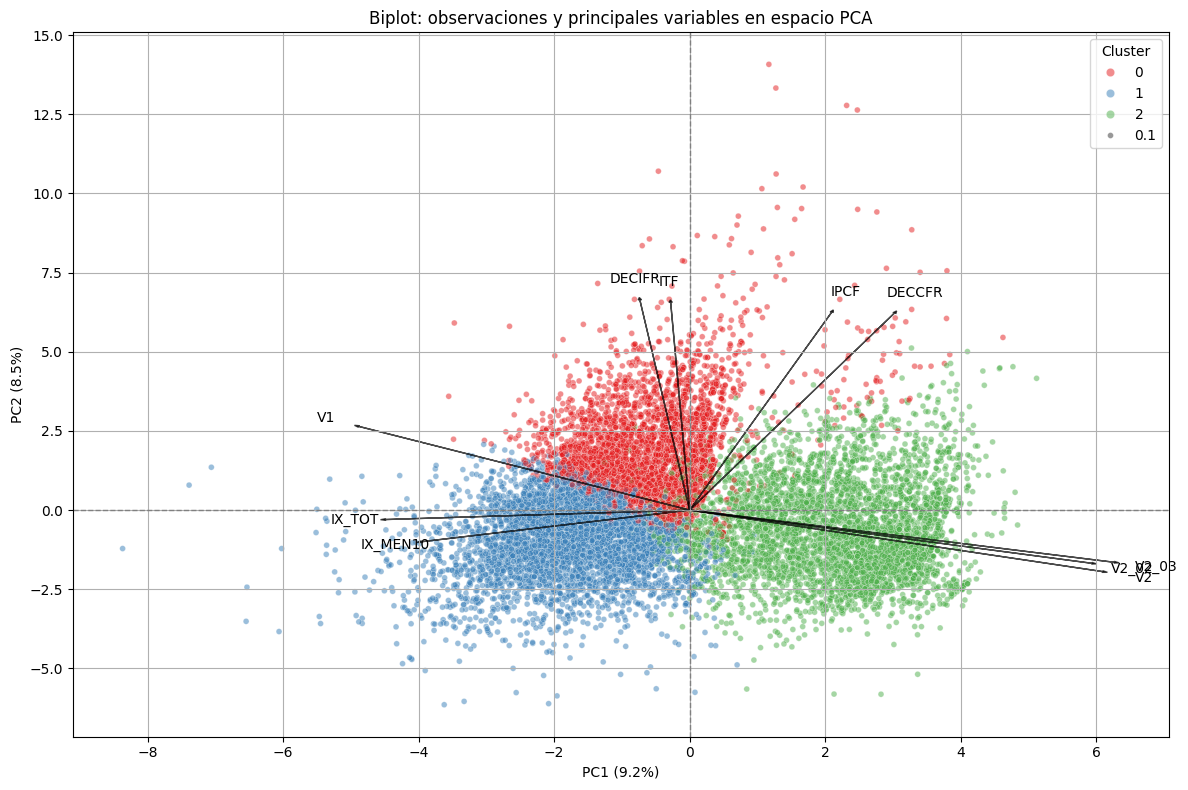

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

# PCA e inicialización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# DataFrame con PCA y clusters
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_scaled.index)
df_pca["cluster"] = clusters_3

# Crear gráfico
plt.figure(figsize=(12, 8))

# Scatter plot de observaciones con clusters
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster", size=0.1, palette="Set1", alpha=0.5)

# Agregar vectores de carga (solo los n más importantes)
loadings = pca.components_.T  # shape (n_features, 2)
scale_factor = 15
n_variables_mas_importantes = 10

# Magnitud del vector de carga para cada variable
importance = np.linalg.norm(loadings, axis=1)
top_features_idx = importance.argsort()[-n_variables_mas_importantes:]  # índices de las n más importantes

# Dibujar flechas y etiquetas
for i in top_features_idx:
    x = loadings[i, 0] * scale_factor
    y = loadings[i, 1] * scale_factor
    plt.arrow(0, 0, x, y, color='black', alpha=0.7, head_width=0.05)
    plt.text(x * 1.1, y * 1.1, X_scaled.columns[i], color='black', ha='center', va='center')

# Títulos y ajustes
plt.title("Biplot: observaciones y principales variables en espacio PCA")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True)
plt.axhline(0, color='grey', lw=1, linestyle='--')
plt.axvline(0, color='grey', lw=1, linestyle='--')
plt.tight_layout()
plt.legend(title="Cluster")
plt.show()


In [47]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import plotly.graph_objs as go

# PCA con 3 componentes
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# DataFrame con PCA y clusters
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"], index=X_scaled.index)
df_pca["cluster"] = clusters_3

# Cálculo de vectores de carga
loadings = pca.components_.T  # shape (n_features, 3)
scale_factor = 10
n_variables_mas_importantes = 10

# Magnitud del vector de carga para ordenar
importance = np.linalg.norm(loadings, axis=1)
top_features_idx = importance.argsort()[-n_variables_mas_importantes:]

# Crear traza para puntos (observaciones)
trace_puntos = go.Scatter3d(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    z=df_pca["PC3"],
    mode='markers',
    marker=dict(
        size=3,
        color=df_pca["cluster"],
        colorscale='plasma',
        opacity=0.6
    ),
    text=df_pca.index,
    name='Observaciones'
)

# Crear trazas para flechas (vectores de carga)
traces_flechas = []
for i in top_features_idx:
    x, y, z = loadings[i] * scale_factor
    traces_flechas.append(
        go.Scatter3d(
            x=[0, x],
            y=[0, y],
            z=[0, z],
            mode='lines+text',
            line=dict(color='black', width=4),
            text=[None, X_scaled.columns[i]],
            textposition="top center",
            name=X_scaled.columns[i],
            showlegend=False
        )
    )

# Layout
layout = go.Layout(
    title="Biplot 3D: observaciones y variables en espacio PCA",
    scene=dict(
        xaxis=dict(title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"),
        yaxis=dict(title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"),
        zaxis=dict(title=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

import plotly.graph_objs as go
from plotly.offline import plot

# Tu figura como antes
fig = go.Figure(data=[trace_puntos] + traces_flechas, layout=layout)

# Mostrar como HTML en una nueva pestaña
plot(fig)  # Esto abre un enlace en el output


'temp-plot.html'

In [48]:
# Le agregamos la descripción. Estamos viendo la influencia que tiene cada variable en la componente principal analizada. Vean igual que solo explicamos un 18% de variabilidad de los datos con 2 componentes.
pca_components_sorted.index.name = "variable"
pca_components_sorted.join(df_desc)

,PC1,PC2,descripcion
variable,,,
V2_03,0.417876,0.109891,Monto total jubilación/pensión
V2,0.406364,0.129490,Reciben jubilación o pensión
V2_02,0.395841,0.112013,Cantidad de perceptores de jubilación
V1,0.325417,0.176042,Viven de lo que ganan en el trabajo
IX_TOT,0.299204,0.019912,Cantidad total de miembros del hogar
IX_MEN10,0.263736,0.066625,Cantidad de miembros menores de 10 años
IX_MAYEQ10,0.231582,0.009223,Cantidad de miembros de 10 años o más
DECCFR,0.201514,0.414695,Decil de ingreso per cápita familiar
V22_01,0.152693,0.073385,Reciben pensión por invalidez


##### Visualización

Hagamos una representación en un mapa de los resultados obtenidos. Usaremos nuevamente GeoPandas como herramienta, por lo que deberemos definir objetos especiales atados a cada instancia.

In [49]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
%pip install contextily
import contextily as ctx
%%capture

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 51.3 MB/s eta 0:00:00


UsageError: Line magic function `%%capture` not found.


 Visualización de instancias de cada cluster

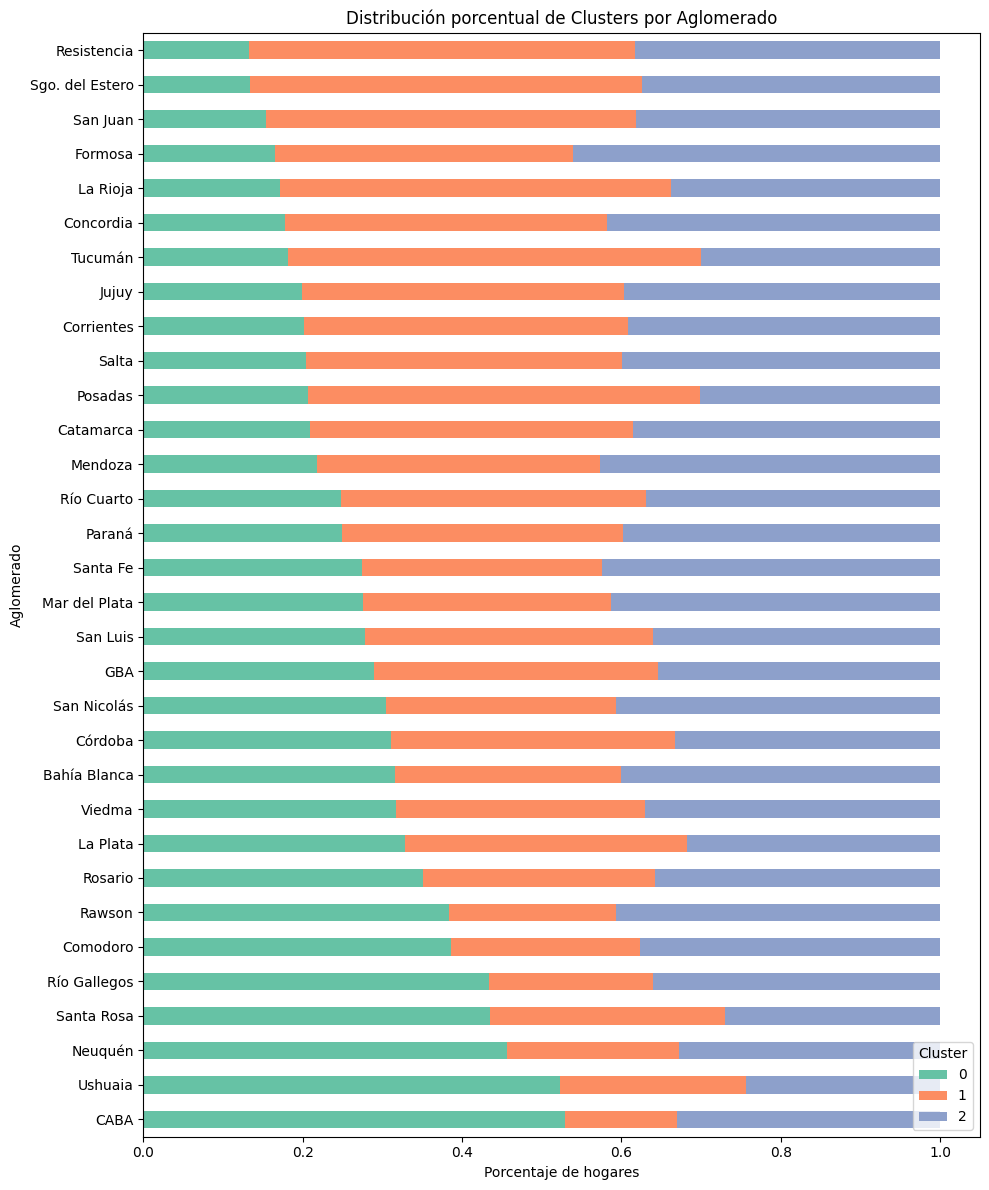

In [50]:

# Calcular proporción de cada cluster por aglomerado
df_pct = df_clusters_3.groupby("AGLOMERADO")["cluster"].value_counts(normalize=True).unstack(fill_value=0)

# Ordenar por total del primer cluster (opcional)
df_pct = df_pct.loc[df_pct[0].sort_values(ascending=False).index]

# Mapear nombres de aglomerado
nombres_aglo = {
    "2": "La Plata", "3": "Bahía Blanca", "4": "Rosario", "5": "Santa Fe", "6": "Paraná",
    "7": "Posadas", "8": "Resistencia", "9": "Comodoro", "10": "Mendoza", "12": "Corrientes",
    "13": "Córdoba", "14": "Concordia", "15": "Formosa", "17": "Neuquén", "18": "Sgo. del Estero",
    "19": "Jujuy", "20": "Río Gallegos", "22": "Catamarca", "23": "Salta", "25": "La Rioja",
    "26": "San Luis", "27": "San Juan", "29": "Tucumán", "30": "Santa Rosa", "31": "Ushuaia",
    "32": "CABA", "33": "GBA", "34": "Mar del Plata", "36": "Río Cuarto","38":'San Nicolás',
    "91": "Rawson", "92": "Trelew", "93": "Viedma"
}
df_pct.index = df_pct.index.map(lambda x: nombres_aglo.get(str(x), str(x)))

# Graficar
colors = ["#66c2a5", "#fc8d62", "#8da0cb"]
df_pct.plot(kind="barh", stacked=True, figsize=(10, 12), color=colors)

plt.xlabel("Porcentaje de hogares")
plt.ylabel("Aglomerado")
plt.title("Distribución porcentual de Clusters por Aglomerado")
plt.legend(title="Cluster", loc="lower right")
plt.tight_layout()
plt.show()



Visualización de cluster mayoritario en mapa

In [51]:
# Veamos los aglomerados que agrupa la EPH
df_clusters_3.AGLOMERADO.value_counts()

,count
AGLOMERADO,
33,1257
13,742
23,578
29,503
19,481
32,472
4,447
27,430
22,425


Qué ciudad representa cada número está en la documentación. Usaremos ChatGPT para generar el diccionario con polígonos especiales, pero podríamos recopilarlo nosotros ya que es información pública

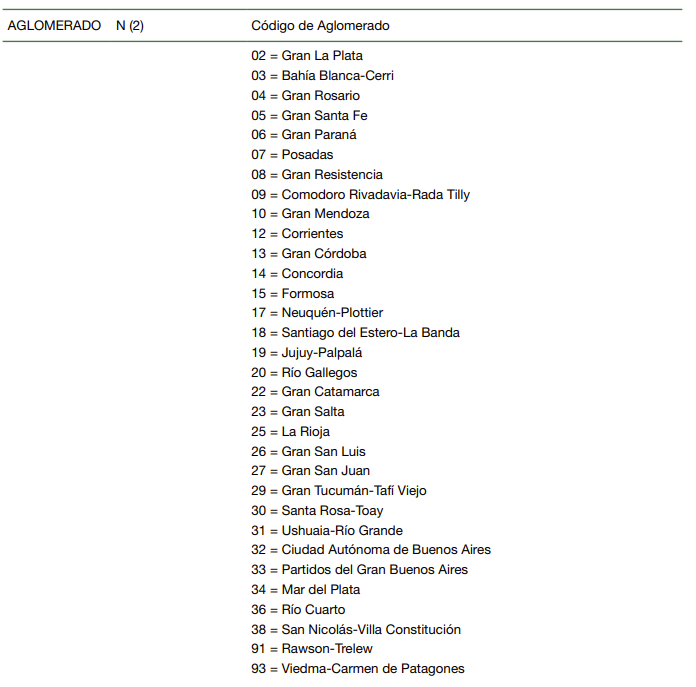


In [52]:
# Asegurarse de que AGLOMERADO esté en formato string
df_clusters_3 = df_clusters_3.copy()
df_clusters_3["AGLOMERADO"] = df_clusters_3["AGLOMERADO"].astype(str)

# Crear DataFrame con coordenadas si no existe
coords_aglo = {
    "02": (-34.9214, -57.9544),
    "03": (-38.7196, -62.2724),
    "04": (-32.9442, -60.6505),
    "05": (-31.6333, -60.7000),
    "06": (-31.7319, -60.5238),
    "07": (-27.3628, -55.9000),
    "08": (-27.4516, -58.9867),
    "09": (-45.8650, -67.4822),
    "10": (-32.8897, -68.8444),
    "12": (-27.4806, -58.8341),
    "13": (-31.4201, -64.1888),
    "14": (-31.3889, -58.0178),
    "15": (-26.1775, -58.1781),
    "17": (-38.9516, -68.0591),
    "18": (-27.7951, -64.2615),
    "19": (-24.1858, -65.2995),
    "20": (-51.6236, -69.2168),
    "22": (-28.4696, -65.7852),
    "23": (-24.7829, -65.4232),
    "25": (-29.4110, -66.8507),
    "26": (-33.2993, -66.3363),
    "27": (-31.5370, -68.5258),
    "29": (-26.8326, -65.2049),
    "30": (-36.6208, -64.2906),
    "31": (-54.8050, -68.3030),
    "32": (-34.6037, -58.3816),
    "33": (-34.7000, -58.5000),
    "34": (-38.0055, -57.5426),
    "36": (-33.1236, -64.3499),
    "91": (-33.3371, -60.2167),
    "92": (-43.2994, -65.1022),
    "93": (-40.8122, -63.0000)
}



In [53]:
# Crear DataFrame de coordenadas
df_coords = pd.DataFrame.from_dict(coords_aglo, orient='index', columns=["lat", "lon"])
df_coords.index.name = "AGLOMERADO"
df_coords.reset_index(inplace=True)

# Agrupar por aglomerado y obtener cluster más frecuente
df_cluster_aglo = df_clusters_3.groupby("AGLOMERADO")["cluster"].agg(lambda x: x.value_counts().idxmax()).reset_index()

# Unir coordenadas con cluster
df_map = pd.merge(df_cluster_aglo, df_coords, on="AGLOMERADO", how="left")

# Crear GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_map,
    geometry=[Point(xy) for xy in zip(df_map["lon"], df_map["lat"])],
    crs="EPSG:4326"
)
# Convertir a Web Mercator (necesario para contextily)
gdf_mercator = gdf.to_crs(epsg=3857)



In [54]:
gdf

,AGLOMERADO,cluster,lat,lon,geometry
0,10,2,-32.8897,-68.8444,POINT (-68.8444 -32.8897)
1,12,1,-27.4806,-58.8341,POINT (-58.8341 -27.4806)
2,13,1,-31.4201,-64.1888,POINT (-64.1888 -31.4201)
3,14,2,-31.3889,-58.0178,POINT (-58.0178 -31.3889)
4,15,2,-26.1775,-58.1781,POINT (-58.1781 -26.1775)
5,17,0,-38.9516,-68.0591,POINT (-68.0591 -38.9516)
6,18,1,-27.7951,-64.2615,POINT (-64.2615 -27.7951)
7,19,1,-24.1858,-65.2995,POINT (-65.2995 -24.1858)
8,2,1,NaN,NaN,POINT (NaN NaN)
9,20,0,-51.6236,-69.2168,POINT (-69.2168 -51.6236)


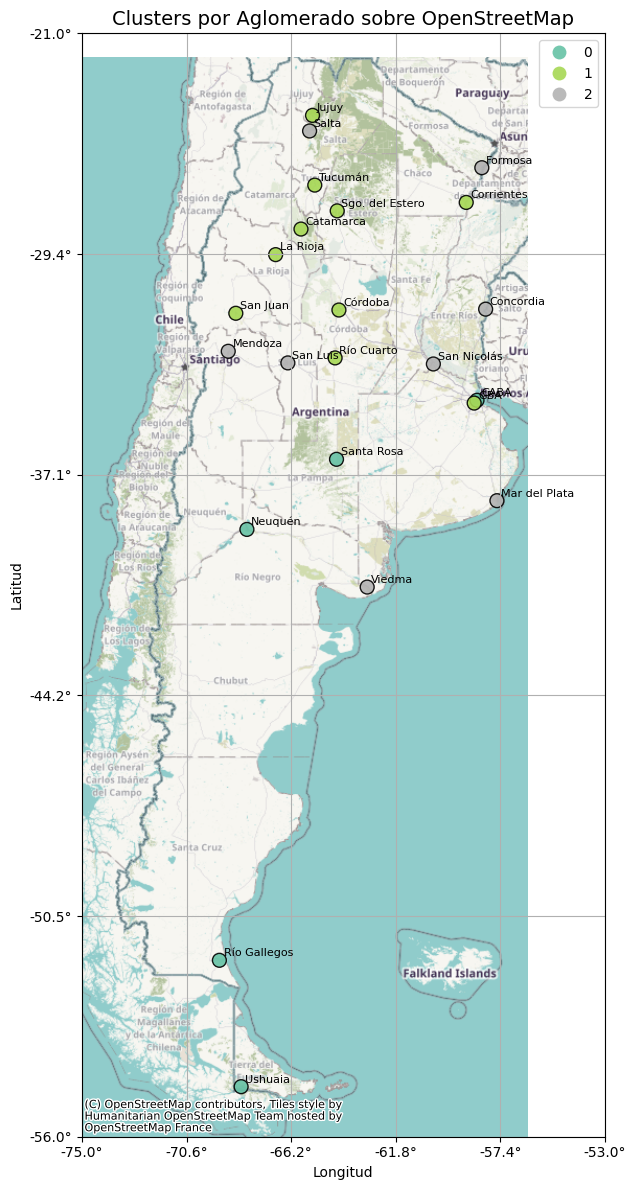

In [55]:
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
from pyproj import Transformer

# Volvemos a convertir a Web Mercator (EPSG:3857) para contextily
gdf_mercator = gdf.to_crs(epsg=3857)

# Establecer límites típicos de Argentina
xmin, xmax = -75, -53
ymin, ymax = -56, -21
transformer = Transformer.from_crs("epsg:4326", "epsg:3857", always_xy=True)
xmin_m, ymin_m = transformer.transform(xmin, ymin)
xmax_m, ymax_m = transformer.transform(xmax, ymax)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 12))
gdf_mercator.plot(
    ax=ax,
    column="cluster",
    categorical=True,
    cmap="Set2",
    legend=True,
    markersize=100,
    edgecolor="black",
    alpha=0.9
)

# Agregar etiquetas con nombre del aglomerado (si tenés un diccionario de nombres)
nombres_aglo = {
    "02": "La Plata", "03": "Bahía Blanca", "04": "Rosario", "05": "Santa Fe", "06": "Paraná",
    "07": "Posadas", "08": "Resistencia", "09": "Comodoro", "10": "Mendoza", "12": "Corrientes",
    "13": "Córdoba", "14": "Concordia", "15": "Formosa", "17": "Neuquén", "18": "Sgo. del Estero",
    "19": "Jujuy", "20": "Río Gallegos", "22": "Catamarca", "23": "Salta", "25": "La Rioja",
    "26": "San Luis", "27": "San Juan", "29": "Tucumán", "30": "Santa Rosa", "31": "Ushuaia",
    "32": "CABA", "33": "GBA", "34": "Mar del Plata", "36": "Río Cuarto",
    "91": "San Nicolás", "92": "Trelew", "93": "Viedma"
}

for idx, row in gdf_mercator.iterrows():
    aglo = row["AGLOMERADO"]
    nombre = nombres_aglo.get(aglo, aglo)
    ax.annotate(
        nombre,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
        color="black"
    )

# Agregar mapa base limpio
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.HOT)

# Ajustar límites y ejes con grados
ax.set_xlim(xmin_m, xmax_m)
ax.set_ylim(ymin_m, ymax_m)

xticks = np.linspace(xmin_m, xmax_m, 6)
yticks = np.linspace(ymin_m, ymax_m, 6)
inv_transformer = Transformer.from_crs("epsg:3857", "epsg:4326", always_xy=True)
xticks_deg = [inv_transformer.transform(x, ymin_m)[0] for x in xticks]
yticks_deg = [inv_transformer.transform(xmin_m, y)[1] for y in yticks]

ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:.1f}°" for x in xticks_deg])
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.1f}°" for y in yticks_deg])

# Etiquetas finales
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Clusters por Aglomerado sobre OpenStreetMap", fontsize=14)
ax.grid(True)
plt.tight_layout()
plt.show()
